In [2]:
import os

data_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
os.listdir(data_dir)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [3]:
import shutil
import os

# Define source and destination paths
source_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
dest_dir = '/kaggle/working/brain-tumor-mri-dataset/Training'

# Copy the entire directory
shutil.copytree(source_dir, dest_dir)

# List the copied files to ensure they've been copied
os.listdir(dest_dir)


['notumor', 'meningioma', 'glioma', 'pituitary']

In [4]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

In [5]:
import hashlib

def dhash(image, hash_size=8):
    resized = cv2.resize(image, (hash_size + 1, hash_size))
    diff = resized[:, 1:] > resized[:, :-1]
    return sum([2 ** i for (i, v) in enumerate(diff.flatten()) if v])

def remove_duplicates(data_dir):
    image_hashes = {}
    duplicates = []

    for category in os.listdir(data_dir):
        category_path = os.path.join(dest_dir, category)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img_hash = dhash(img)

            if img_hash in image_hashes:
                print(f"Duplicate found: {img_name} is a duplicate of {image_hashes[img_hash]}")
                duplicates.append(img_path)
            else:
                image_hashes[img_hash] = img_name

    for duplicate in duplicates:
        os.remove(duplicate)
        print(f"Deleted duplicate image: {duplicate}")

remove_duplicates(dest_dir)

Duplicate found: Tr-no_1027.jpg is a duplicate of Tr-no_0205.jpg
Duplicate found: Tr-no_0330.jpg is a duplicate of Tr-no_0971.jpg
Duplicate found: Tr-no_1135.jpg is a duplicate of Tr-no_0234.jpg
Duplicate found: Tr-no_0332.jpg is a duplicate of Tr-no_0350.jpg
Duplicate found: Tr-no_0012.jpg is a duplicate of Tr-no_0298.jpg
Duplicate found: Tr-no_1173.jpg is a duplicate of Tr-no_0059.jpg
Duplicate found: Tr-no_0985.jpg is a duplicate of Tr-no_0345.jpg
Duplicate found: Tr-no_0052.jpg is a duplicate of Tr-no_0352.jpg
Duplicate found: Tr-no_0335.jpg is a duplicate of Tr-no_0394.jpg
Duplicate found: Tr-no_0011.jpg is a duplicate of Tr-no_0298.jpg
Duplicate found: Tr-no_0122.jpg is a duplicate of Tr-no_0119.jpg
Duplicate found: Tr-no_1070.jpg is a duplicate of Tr-no_0028.jpg
Duplicate found: Tr-no_0982.jpg is a duplicate of Tr-no_0350.jpg
Duplicate found: Tr-no_0076.jpg is a duplicate of Tr-no_0081.jpg
Duplicate found: Tr-no_1068.jpg is a duplicate of Tr-no_0026.jpg
Duplicate found: Tr-no_10

In [21]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def load_and_preprocess_images(data_dir, target_size=(256, 256)):
    images = []
    for img_name in os.listdir(data_dir):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(data_dir, img_name)
            img = load_img(img_path, color_mode='grayscale', target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
    
    return np.array(images)

def normalize_images(images):
    return (images / 127.5) - 1

def create_datasets(images, batch_size=32, validation_split=0.2):
    train_images, val_images = train_test_split(images, test_size=validation_split, random_state=42)
    
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(1000).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices(val_images).batch(batch_size)
    
    return train_dataset, val_dataset

def preprocess_mri_dataset(data_dir, target_size=(256, 256), batch_size=32, validation_split=0.2):
    images = load_and_preprocess_images(data_dir, target_size)
    normalized_images = normalize_images(images)
    train_dataset, val_dataset = create_datasets(normalized_images, batch_size, validation_split)
    return train_dataset, val_dataset

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_generator(latent_dim, output_shape):
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(16 * 16 * 256),
        layers.Reshape((16, 16, 256)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(16, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Conv2D(1, kernel_size=3, padding='same', activation='tanh')
    ])
    return model

def build_discriminator(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

class GAN(models.Model):
    def __init__(self, latent_dim, input_shape):
        super(GAN, self).__init__()
        self.latent_dim = latent_dim
        self.input_shape = input_shape
        self.generator = build_generator(latent_dim, input_shape)
        self.discriminator = build_discriminator(input_shape)
        
        # Initialize optimizers and loss function
        self.g_optimizer = None
        self.d_optimizer = None
        self.loss_fn = None

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(GAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    @tf.function
    def train_step(self, real_images):
        if real_images.shape[1:] != self.input_shape:
            raise ValueError(f"Expected input shape {self.input_shape}, but got {real_images.shape[1:]}")
        
        batch_size = tf.shape(real_images)[0]
        latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(latent_vectors, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)
            disc_loss = self.loss_fn(tf.ones_like(real_output), real_output) + \
                        self.loss_fn(tf.zeros_like(fake_output), fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))
        
        return {"d_loss": disc_loss, "g_loss": gen_loss}

# Hyperparameters
latent_dim = 100
input_shape = (256, 256, 1)
batch_size = 32
epochs = 100
learning_rate = 0.0002
beta_1 = 0.5

# Create and compile the GAN
gan = GAN(latent_dim, input_shape)
gan.compile(
    g_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    d_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
)

# Assuming you have already preprocessed your dataset
# train_dataset = ...

# Train the GAN
# gan.fit(train_dataset, epochs=epochs)

In [31]:
def generate_and_save_images(gan, epoch):
    test_input = tf.random.normal([16, gan.latent_dim])
    predictions = gan.generator(test_input, training=False)
    
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    
    plt.savefig(f'generated_image_epoch_{epoch}.png')
    plt.close()
    

def train_gan(gan, dataset, epochs, batch_size):
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        for batch in dataset:
            try:
                gan.train_step(batch)
            except Exception as e:
                print(f"Error during training: {str(e)}")
                print(f"Batch shape: {batch.shape}")
                print(f"Batch dtype: {batch.dtype}")
                return  # Exit the function if an error occurs
        
        # Generate and save sample images
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(gan, epoch + 1)

In [32]:
latent_dim = 100
input_shape = (256, 256, 1)
batch_size = 32
epochs = 100
learning_rate = 0.0002
beta_1 = 0.5

# Load and preprocess the dataset
data_dir = '/kaggle/working/brain-tumor-mri-dataset/Training/notumor'
train_dataset, val_dataset = preprocess_mri_dataset(data_dir, input_shape[:2], batch_size)

In [33]:
for batch in train_dataset.take(1):
    print(f"Sample batch shape: {batch.shape}")
    print(f"Sample batch dtype: {batch.dtype}")
    if batch.shape[1:] != input_shape:
        raise ValueError(f"Dataset shape {batch.shape[1:]} does not match expected input shape {input_shape}")
#test_input = val_dataset
train_gan(gan, train_dataset, epochs, batch_size)

Sample batch shape: (32, 256, 256, 1)
Sample batch dtype: <dtype: 'float32'>
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/

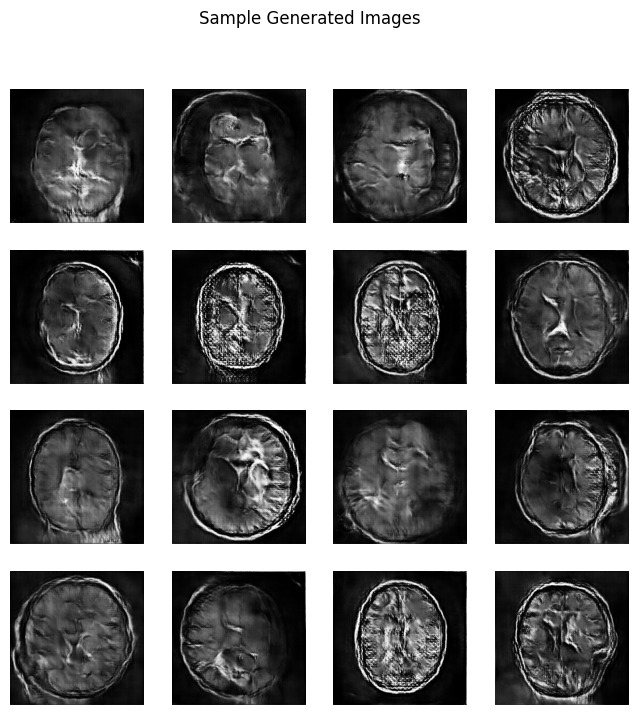

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def generate_images(gan, latent_dim, num_images=16):
    """
    Generate images using the GAN's generator.

    Parameters:
        gan (GAN model): The trained GAN model.
        latent_dim (int): The dimensionality of the latent space.
        num_images (int): Number of images to generate.

    Returns:
        numpy array: Generated images.
    """
    # Generate random latent vectors
    latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    
    # Generate images from latent vectors
    generated_images = gan.generator(latent_vectors, training=False)
    
    # Convert the generated images to numpy arrays and scale to [0, 1]
    generated_images = (generated_images + 1) / 2.0  # Assuming images are normalized to [-1, 1]

    return generated_images.numpy()

def plot_generated_images(images, title="Generated Images"):
    """
    Plot multiple generated images in a grid.

    Parameters:
        images (numpy array): The images to display.
        title (str): Title of the plot.
    """
    num_images = images.shape[0]
    grid_size = int(np.sqrt(num_images))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')  # Assuming grayscale images; adjust for RGB if needed
        plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

# Example usage
latent_dim = 100  # The dimension of the latent space used in your GAN
num_images = 16    # Number of images to generate

# Generate images from the GAN model
generated_images = generate_images(gan, latent_dim, num_images)

# Plot the generated images
plot_generated_images(generated_images, title="Sample Generated Images")


In [36]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from scipy.linalg import sqrtm

def preprocess_images_for_inception(images, target_size=(299, 299)):
    processed_images = []
    for img in images:
        img = tf.image.resize(img, target_size)
        img = tf.image.grayscale_to_rgb(img)  # Convert grayscale to RGB
        img = preprocess_input(img)  # Preprocess for InceptionV3
        processed_images.append(img)
    return np.array(processed_images)

def calculate_fid(real_images, generated_images):
    model = InceptionV3(include_top=False, pooling='avg', weights='imagenet')
    
    def get_features(images):
        images = preprocess_images_for_inception(images)
        features = model.predict(images)
        return features
    
    def calculate_activation_statistics(features):
        mean = np.mean(features, axis=0)
        cov = np.cov(features, rowvar=False)
        return mean, cov
    
    real_features = get_features(real_images)
    generated_features = get_features(generated_images)
    
    real_mean, real_cov = calculate_activation_statistics(real_features)
    gen_mean, gen_cov = calculate_activation_statistics(generated_features)
    
    mean_diff = real_mean - gen_mean
    cov_sqrt, _ = sqrtm(real_cov @ gen_cov, disp=False)
    fid = np.sum(mean_diff**2) + np.trace(real_cov + gen_cov - 2 * cov_sqrt)
    return fid

# Example usage
# Assuming `real_images` and `generated_images` are numpy arrays
# with shape (num_samples, height, width, channels)


In [39]:
import tensorflow as tf
import numpy as np

def inception_score(images, batch_size=32, splits=10):
    model = tf.keras.applications.InceptionV3(include_top=True, weights='imagenet')
    model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
    
    def preprocess_images(images):
        images = [tf.image.resize(img, (299, 299)) for img in images]
        images = [tf.image.grayscale_to_rgb(img) for img in images]  # Convert grayscale to RGB
        images = tf.keras.applications.inception_v3.preprocess_input(np.array(images))
        return images
    
    def _softmax(x):
        return tf.nn.softmax(x)

    def _kl_divergence(p, q):
        return np.sum(p * np.log(p / q), axis=1)
    
    def _calculate_scores(preds):
        scores = []
        for i in range(splits):
            split_preds = preds[i * (len(preds) // splits):(i + 1) * (len(preds) // splits)]
            split_preds = _softmax(split_preds)
            kl_div = _kl_divergence(np.mean(split_preds, axis=0), split_preds)
            scores.append(np.exp(np.mean(kl_div)))
        return np.mean(scores)
    
    images = preprocess_images(images)
    preds = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch_preds = model.predict(batch)
        preds.append(batch_preds)
    
    preds = np.concatenate(preds)
    score = _calculate_scores(preds)
    return score

# Example usage
# Assuming `images` is a numpy array with shape (num_samples, height, width, channels)


In [40]:
def evaluate_gan(gan, val_dataset):
    num_images = 1000
    latent_dim = gan.latent_dim
    generated_images = []
    
    for _ in range(num_images // batch_size):
        latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        batch_generated_images = gan.generator(latent_vectors, training=False)
        generated_images.append(batch_generated_images.numpy())
    
    generated_images = np.concatenate(generated_images)
    
    # Prepare real images for evaluation
    real_images = []
    for batch in val_dataset:
        real_images.append(batch.numpy())
    real_images = np.concatenate(real_images)
    
    # Compute FID and IS
    fid_score = calculate_fid(real_images, generated_images)
    is_score = inception_score(generated_images)
    
    print(f"FID Score: {fid_score}")
    print(f"Inception Score: {is_score}")
evaluate_gan(gan, val_dataset)

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 605ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/ste